# Demand Mapping
Overlays ticket boarding counts onto GeoJSON route geometries to identify high-demand corridors.

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

In [ ]:
["gdf_routes = gpd.read_file(r'..\auxiliar_data\line_routes.json')\n\nticket_path = r'..\data\\anonymized\\2026-03-11.csv'\nif not os.path.exists(ticket_path):\n    raise FileNotFoundError(f'Ticket file not found: {ticket_path}')\ndf_tickets = pd.read_csv(ticket_path)\n\nroute_demand = df_tickets.groupby('route_name').size().reset_index(name='total_boardings')\nprint(f'{len(gdf_routes)} route shapes | {len(df_tickets):,} ticket records | {len(route_demand)} routes')"]

Loading Spatial Geometries and Ticket Data...
Loaded 43 geographic route shapes.
GeoJSON columns: ['OBJECTID', 'tx_nome', 'db_extensao', 'Shape__Length', 'geometry']
Loaded 267,132 ticket records.
Calculated demand for 56 routes.


In [ ]:
def extract_route_key(tx_nome):
    key = tx_nome.lstrip('L')
    for suffix in ['_Ida', '_Volta', '_Circular']:
        if suffix in key:
            key = key[:key.rfind(suffix)]
    key = key.replace('_', '.')
    try:
        key = str(int(float(key))) if key.replace('.', '', 1).isdigit() else key
    except Exception:
        pass
    return key

gdf_routes['route_key'] = gdf_routes['tx_nome'].apply(extract_route_key)
route_demand['route_name'] = route_demand['route_name'].astype(str)

gdf_mapped = gdf_routes.merge(route_demand, left_on='route_key', right_on='route_name', how='left')
gdf_mapped['total_boardings'] = gdf_mapped['total_boardings'].fillna(0)

matched = (gdf_mapped['total_boardings'] > 0).sum()
print(f'{matched}/{len(gdf_mapped)} routes matched')

Sample GeoJSON route keys:      tx_nome route_key
L03_Circular         3
     L15_Ida        15
   L15_Volta        15
     L22_Ida        22
   L22_Volta        22
     L21_Ida        21
   L21_Volta        21
     L24_Ida        24
   L24_Volta        24
     L26_Ida        26
Spatial Merge Complete! 29 of 43 routes matched with passenger data.


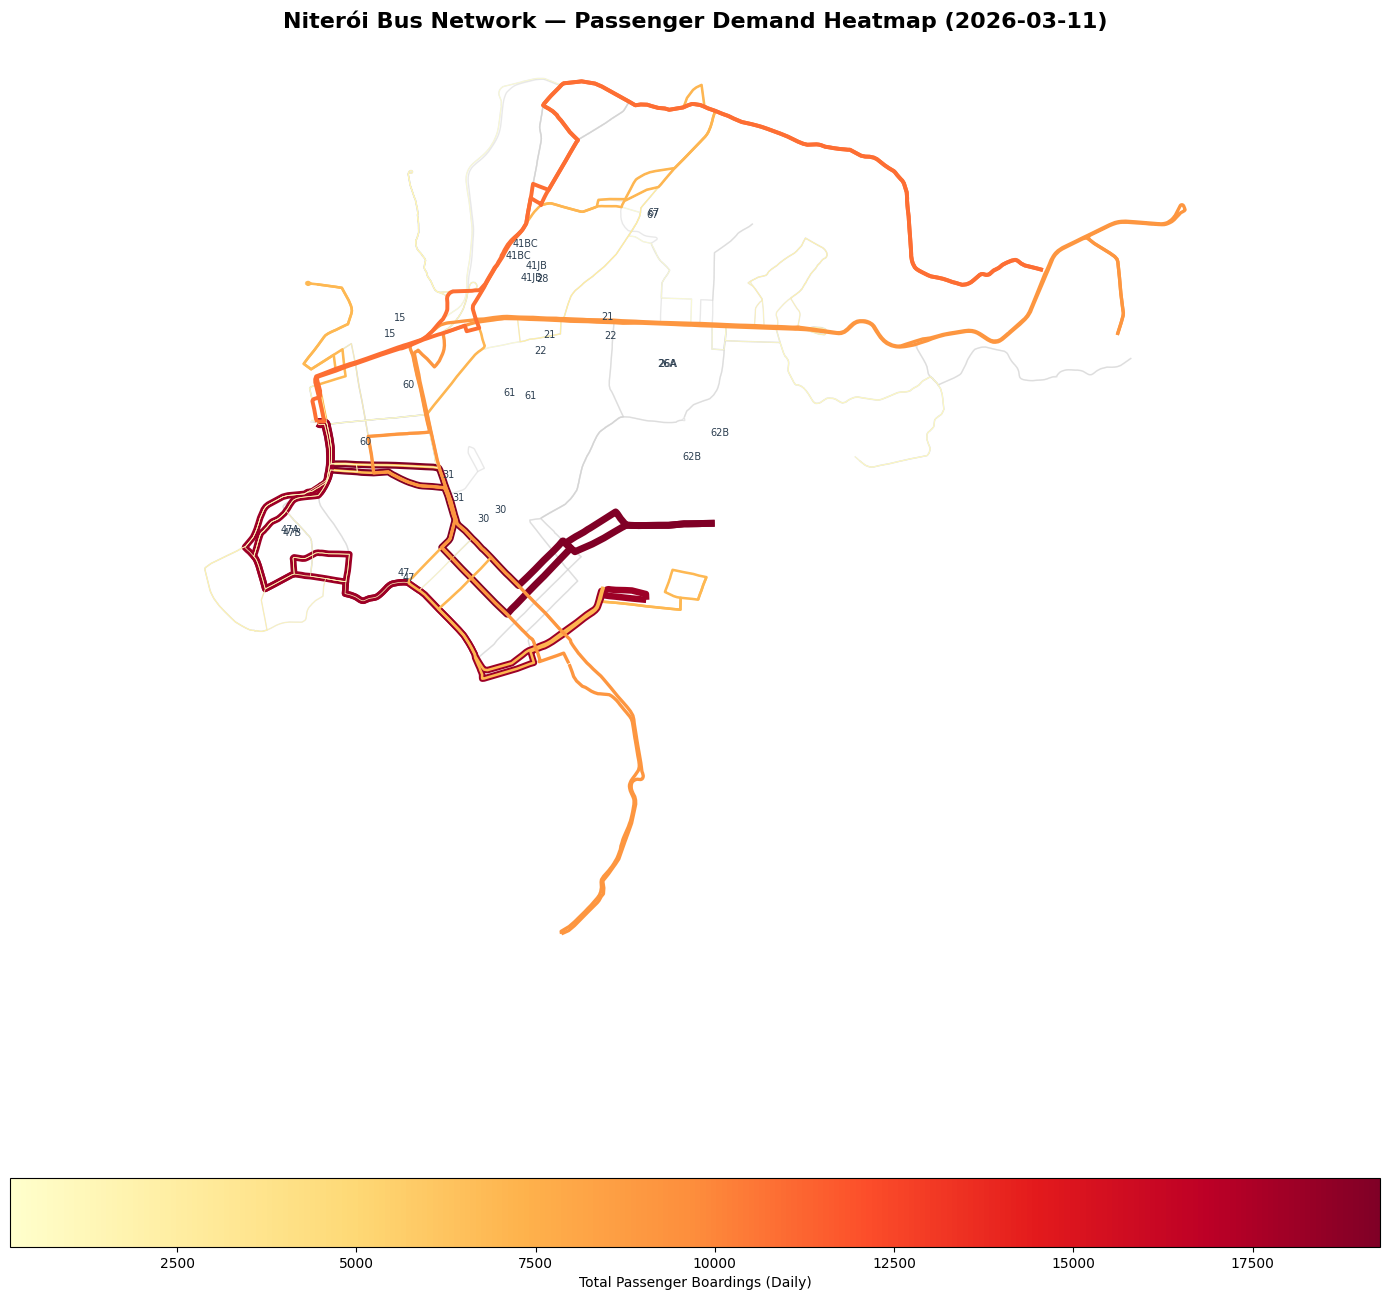


Top 5 demand routes on this day:
   route_key  total_boardings
16        30          19278.0
15        30          19278.0
29        47          18084.0
30        47          18084.0
41        67          10888.0


In [ ]:
fig, ax = plt.subplots(figsize=(14, 14))

gdf_mapped.plot(ax=ax, color='lightgrey', linewidth=1, alpha=0.5)

high_demand = gdf_mapped[gdf_mapped['total_boardings'] > 0].copy()
max_boardings = high_demand['total_boardings'].max()

high_demand.plot(
    column='total_boardings',
    ax=ax,
    cmap='YlOrRd',
    linewidth=(high_demand['total_boardings'] / max_boardings * 5).clip(lower=0.5),
    legend=True,
    legend_kwds={'label': 'Total Boardings (Daily)', 'orientation': 'horizontal'}
)

for _, row in high_demand.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(row['route_key'], xy=(centroid.x, centroid.y), fontsize=7, ha='center', color='#2c3e50')

plt.title('Niterói Bus Network — Demand Heatmap (2026-03-11)', fontsize=16, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()

gdf_mapped[['route_key', 'total_boardings']].sort_values('total_boardings', ascending=False).head()